# Training Schemes

In this example, we explore different optimization schemes for training deep neural networks. We use Batch Gradient Descent, Mini-Batch Gradient Descent and Stochastic Gradient Descent.


## Stage 1: Data Definition.

For this example, we use the synthetic dataset available in the [link](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html). It configures a binary classification problem.

In [ ]:
# Required Libraries
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import numpy as np
import time

# DNN libraries
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
# We define some useful functions

def plot_dataset(X, y, axes):
    plt.figure(figsize=(4, 3), dpi=160)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b+")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r+")
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)


def plot_predictions(X, y, model, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_ = np.c_[x0.ravel(), x1.ravel()]
    with torch.no_grad():
      y_pred = model(torch.tensor(X_).float()).reshape(x0.shape)
    plot_dataset(X, y, axes)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.coolwarm, alpha=0.2)

We built a dataset with $300$ samples. We use the 80% for training and the remaining 20% for testing.

In [ ]:
n = 300
X, y = make_moons(n_samples=n, noise=0.05, random_state=42)
train_size = int(n * 0.8)

x_train, x_test = X[:train_size,:], X[train_size:,:]
y_train, y_test = y[:train_size], y[train_size:]

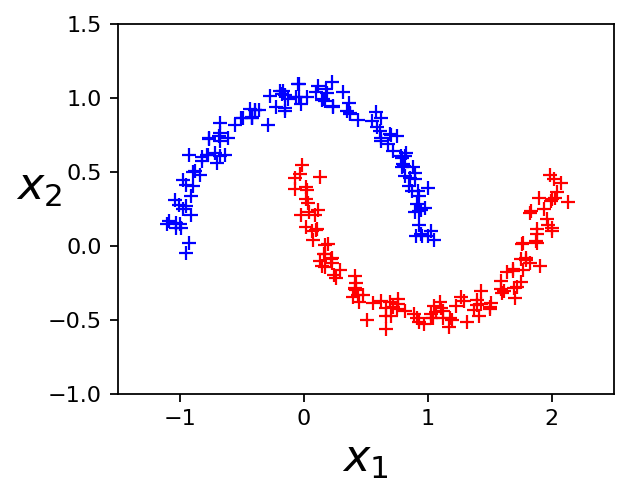

In [ ]:
plot_dataset(x_train, y_train, [-1.5, 2.5, -1, 1.5])
plt.show()

In [ ]:
#Defining the data containers
X_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train.reshape(-1,1)).float()
X_test = torch.tensor(x_test).float()
y_test = torch.tensor(y_test.reshape(-1,1)).float()

## Stage 2: We define the model

We write some useful functions to define and train the neural network. The training processes will be performed by three optimizers:

- Batch Gradient Descent
- Stochastic Gradient Descent
- MiniBatch Gradient Descent

In [ ]:
# A class to define the DNN
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(2, 32), # The input layer has 2 units.
            nn.ReLU(),
            nn.Linear(32, 16), # The input layer has 2 units.
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid() # This activation function maps the real values in the
                         # outputs to probabilites.
        )

    def forward(self, x):
        # This method is used to compute the output given a particular input x.
        logits = self.linear_relu_stack(x)
        return logits

# We do this to use the GPU (if we only use CPU, the training will take a lot of time)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cpu


In [ ]:
# We define a function to train the DNN model. We need to specify the batch size
def fit_model(model, train_dataloader, test_dataloader, epochs):
  learning_rate = 0.01
  loss_fn = nn.BCELoss()

  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


  loss_tr = []
  loss_te = []
  for epoch in range(epochs):
    for x, y in train_dataloader:
      # The variable should be sent to the GPU
      x = x.to(device)
      y = y.to(device)
      # Make predictions
      model.train()
      y_pred = model(x)
      # Compute the loss of current predictions
      loss = loss_fn(y_pred, y)
      # Clean the gradients
      optimizer.zero_grad()
      # Perform backpropagation
      loss.backward()
      # update weights
      optimizer.step()

    # since we're not training, we don't need to calculate the gradients for our outputs
    loss_test = 0
    with torch.no_grad():
      for data in test_dataloader:
          x, labels = data
          x = x.to(device)
          labels = labels.to(device)
          # calculate outputs by running images through the network
          outputs = model(x)
          loss_test += loss_fn(outputs, labels).item() * labels.size(0)

    # Storing the training and test losses
    loss_tr.append(loss.item())
    loss_te.append(loss_test/len(test_dataloader.dataset))
    print("epoch {} loss: {:.4f} test_loss: {:.4f}".format(epoch + 1,loss.item(),loss_test/len(test_dataloader.dataset)))

  return model, loss_tr, loss_te

In [ ]:
# A function to evaluate the model
def evaluate(model, loss_tr, loss_te, test_dataloader, batch_size, epochs):
  correct = 0
  total = 0
  # since we're not training, we don't need to calculate the gradients for our outputs
  with torch.no_grad():
      for data in test_dataloader:
          x, labels = data
          x = x.to(device)
          labels = labels.to(device)
          # calculate outputs by running samples through the network
          outputs = model(x)
          # the class with the highest energy is what we choose as prediction
          predicted = torch.round(outputs.data)
          total += predicted.size(0)
          correct += (predicted[:,0] == labels[:,0]).sum().item()

  print(f'Accuracy of the network on test samples: {100 * correct // total} %')

  plt.plot(loss_tr)
  plt.plot(loss_te, 'r*')
  plt.show()

## Stage 3: Batch Gradient Descent

This first approach corresponds to batch gradient descent. In this optimization method, all available data in the training set is used. In our particular case, the training set consists of 240 samples, so we define:`batch_size = 240`.

All training data is used in each iteration, the epochs parameter used for training indicates the number of iterations.

In [ ]:
# We define the hyperparameters and the loss function
batch_size = 240
epochs = 5000

datasets = torch.utils.data.TensorDataset(X_train, y_train)
train_dataloader = torch.utils.data.DataLoader(datasets, batch_size=batch_size, shuffle=True)

datasets_test = torch.utils.data.TensorDataset(X_test, y_test)
test_dataloader = torch.utils.data.DataLoader(datasets_test, batch_size=batch_size, shuffle=True)

In [ ]:
# We build network
model_bgd = NeuralNetwork()
model_bgd.to(device) # This is to define the model in the GPU

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
start_time = time.time()
model_bgd, loss_tr, loss_te = fit_model(model_bgd, train_dataloader, test_dataloader, epochs)
print(time.time() - start_time, "seconds")

Se han truncado las últimas 5000 líneas del flujo de salida.
epoch 2 loss: 0.6824 test_loss: 0.6874
epoch 3 loss: 0.6820 test_loss: 0.6870
epoch 4 loss: 0.6816 test_loss: 0.6866
epoch 5 loss: 0.6812 test_loss: 0.6862
epoch 6 loss: 0.6808 test_loss: 0.6858
epoch 7 loss: 0.6804 test_loss: 0.6854
epoch 8 loss: 0.6799 test_loss: 0.6850
epoch 9 loss: 0.6795 test_loss: 0.6846
epoch 10 loss: 0.6791 test_loss: 0.6842
epoch 11 loss: 0.6787 test_loss: 0.6838
epoch 12 loss: 0.6783 test_loss: 0.6834
epoch 13 loss: 0.6779 test_loss: 0.6830
epoch 14 loss: 0.6775 test_loss: 0.6826
epoch 15 loss: 0.6771 test_loss: 0.6822
epoch 16 loss: 0.6767 test_loss: 0.6818
epoch 17 loss: 0.6762 test_loss: 0.6814
epoch 18 loss: 0.6758 test_loss: 0.6810
epoch 19 loss: 0.6754 test_loss: 0.6806
epoch 20 loss: 0.6750 test_loss: 0.6801
epoch 21 loss: 0.6746 test_loss: 0.6797
epoch 22 loss: 0.6742 test_loss: 0.6793
epoch 23 loss: 0.6738 test_loss: 0.6789
epoch 24 loss: 0.6733 test_loss: 0.6785
epoch 25 loss: 0.6729 test_

Accuracy of the network on test samples: 95 %


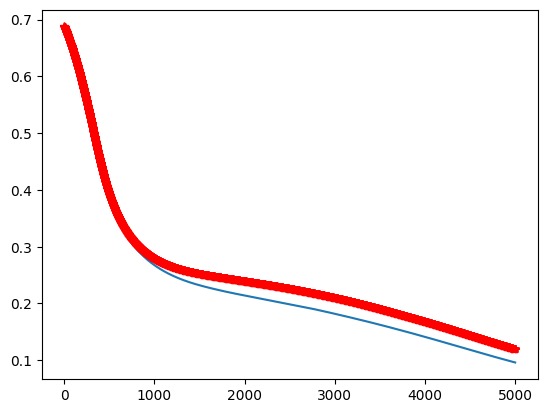

In [ ]:
evaluate(model_bgd, loss_tr, loss_te, test_dataloader, batch_size, epochs)

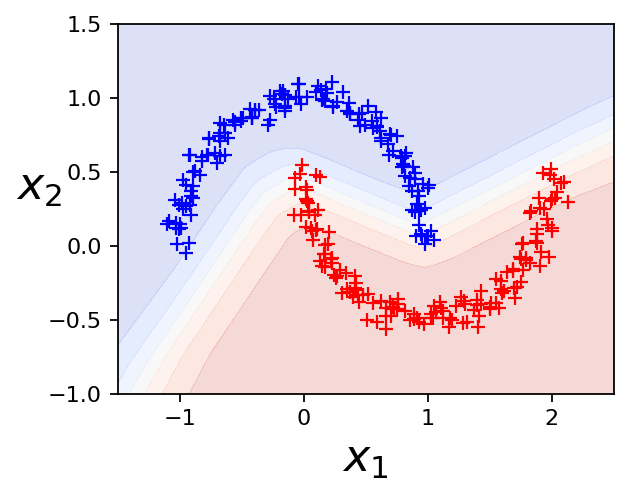

In [ ]:
plot_predictions(X, y, model_bgd, [-1.5, 2.5, -1, 1.5])

## Stage 4: Stochastic Gradient Descent

In stochastic gradient descent, an epoch is considered complete when all training data has been used for optimizing the neural network. In this case, since only one sample is used in each iteration, an epoch is completed in a number of iterations equal to the size of the training set, which in this case is 240 iterations. Additionally, since the epochs parameter is set to 500, the training of the network will be carried out over 120,000 iterations.

In [ ]:
batch_size = 1
epochs = 800

datasets = torch.utils.data.TensorDataset(X_train, y_train)
train_dataloader = torch.utils.data.DataLoader(datasets, batch_size=batch_size, shuffle=True)

datasets_test = torch.utils.data.TensorDataset(X_test, y_test)
test_dataloader = torch.utils.data.DataLoader(datasets_test, batch_size=batch_size, shuffle=True)

In [ ]:
# We build network
model_sgd = NeuralNetwork()
model_sgd.to(device) # This is to define the model in the GPU

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
start_time = time.time()
model_sgd, loss_tr, loss_te = fit_model(model_sgd, train_dataloader, test_dataloader, epochs)
print(time.time() - start_time, "seconds")

epoch 1 loss: 0.6427 test_loss: 0.5983
epoch 2 loss: 0.6583 test_loss: 0.4855
epoch 3 loss: 0.1417 test_loss: 0.3980
epoch 4 loss: 1.2820 test_loss: 0.3345
epoch 5 loss: 0.0554 test_loss: 0.2871
epoch 6 loss: 0.1872 test_loss: 0.2595
epoch 7 loss: 0.4007 test_loss: 0.2318
epoch 8 loss: 0.0462 test_loss: 0.2160
epoch 9 loss: 0.0953 test_loss: 0.1994
epoch 10 loss: 0.0530 test_loss: 0.1841
epoch 11 loss: 0.0076 test_loss: 0.1912
epoch 12 loss: 0.0510 test_loss: 0.1538
epoch 13 loss: 0.0087 test_loss: 0.1398
epoch 14 loss: 0.0095 test_loss: 0.1264
epoch 15 loss: 0.0093 test_loss: 0.1129
epoch 16 loss: 0.0243 test_loss: 0.1140
epoch 17 loss: 0.8042 test_loss: 0.0969
epoch 18 loss: 0.0054 test_loss: 0.0836
epoch 19 loss: 0.0068 test_loss: 0.0733
epoch 20 loss: 0.1847 test_loss: 0.0682
epoch 21 loss: 0.0125 test_loss: 0.0567
epoch 22 loss: 0.0289 test_loss: 0.0508
epoch 23 loss: 0.3194 test_loss: 0.0480
epoch 24 loss: 0.0043 test_loss: 0.0515
epoch 25 loss: 0.0950 test_loss: 0.0389
epoch 26 

Accuracy of the network on test samples: 100 %


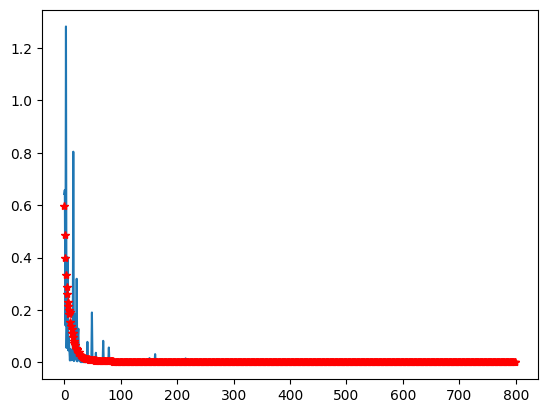

In [ ]:
evaluate(model_sgd, loss_tr, loss_te, test_dataloader, batch_size, epochs)

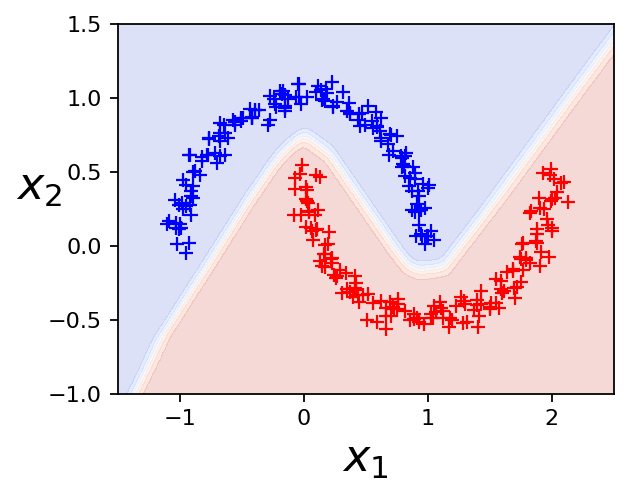

In [ ]:
plot_predictions(X, y, model_sgd, [-1.5, 2.5, -1, 1.5])

## Stage 5: Mini-Batch Gradient Descent

This latter approach presents an intermediate point between stochastic optimization and batch optimization. In this mini-batch optimization scheme, the training set is randomly divided into subsets of size `batch_size`. It should be noted that the `batch_size` value is chosen by the user, thus becoming a new hyperparameter of neural networks.

Following the analysis of the previous approaches, for the mini-batch gradient descent method, an epoch is completed in $\frac{N}{batch\_size}$ iterations, where $N$ is the size of the training set. Thus, the training is carried out in $epochs*\frac{N}{batch\_size}$ iterations.

In [ ]:
batch_size = 32
epochs = 5000

datasets = torch.utils.data.TensorDataset(X_train, y_train)
train_dataloader = torch.utils.data.DataLoader(datasets, batch_size=batch_size, shuffle=True)

datasets_test = torch.utils.data.TensorDataset(X_test, y_test)
test_dataloader = torch.utils.data.DataLoader(datasets_test, batch_size=batch_size, shuffle=True)

In [ ]:
# We build network
model_mbgd = NeuralNetwork()
model_mbgd.to(device) # This is to define the model in the GPU

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
start_time = time.time()
model_mbgd, loss_tr, loss_te = fit_model(model_mbgd, train_dataloader, test_dataloader, epochs)
print(time.time() - start_time, "seconds")

Se han truncado las últimas 5000 líneas del flujo de salida.
epoch 2 loss: 0.6749 test_loss: 0.6747
epoch 3 loss: 0.6690 test_loss: 0.6714
epoch 4 loss: 0.6665 test_loss: 0.6683
epoch 5 loss: 0.6570 test_loss: 0.6654
epoch 6 loss: 0.6530 test_loss: 0.6624
epoch 7 loss: 0.6634 test_loss: 0.6594
epoch 8 loss: 0.6411 test_loss: 0.6563
epoch 9 loss: 0.6298 test_loss: 0.6532
epoch 10 loss: 0.6393 test_loss: 0.6500
epoch 11 loss: 0.6448 test_loss: 0.6468
epoch 12 loss: 0.6158 test_loss: 0.6434
epoch 13 loss: 0.6813 test_loss: 0.6401
epoch 14 loss: 0.6391 test_loss: 0.6365
epoch 15 loss: 0.5976 test_loss: 0.6329
epoch 16 loss: 0.6652 test_loss: 0.6292
epoch 17 loss: 0.6503 test_loss: 0.6253
epoch 18 loss: 0.6431 test_loss: 0.6213
epoch 19 loss: 0.5980 test_loss: 0.6173
epoch 20 loss: 0.5831 test_loss: 0.6132
epoch 21 loss: 0.6453 test_loss: 0.6089
epoch 22 loss: 0.5440 test_loss: 0.6047
epoch 23 loss: 0.5688 test_loss: 0.6005
epoch 24 loss: 0.6787 test_loss: 0.5965
epoch 25 loss: 0.6299 test_

Accuracy of the network on test samples: 100 %


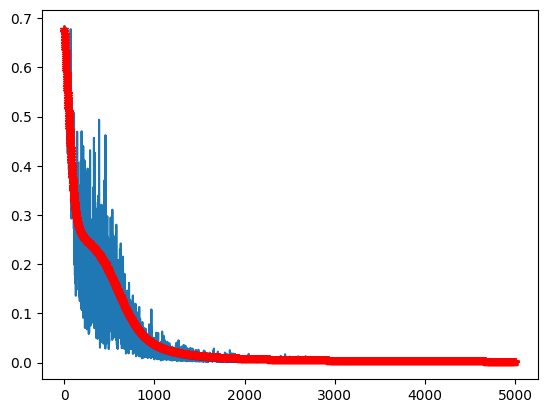

In [ ]:
evaluate(model_mbgd, loss_tr, loss_te, test_dataloader, batch_size, epochs)

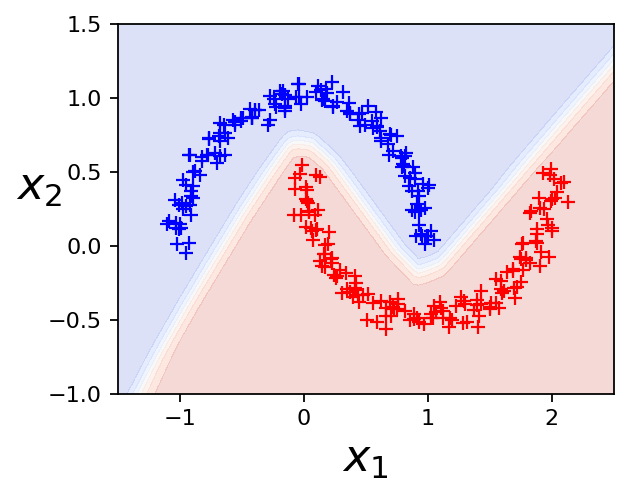

In [ ]:
plot_predictions(X, y, model_mbgd, [-1.5, 2.5, -1, 1.5])